In [15]:
#Load dataset
import pandas as pd
df=pd.read_csv('spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [16]:
df.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [17]:
df=df[['label_num','text']]
df.head()

,label_num,text
0,0,Subject: enron methanol ; meter # : 988291\r\n...
1,0,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,0,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,1,"Subject: photoshop , windows , office . cheap ..."
4,0,Subject: re : indian springs\r\nthis deal is t...


In [18]:
from sklearn.model_selection import train_test_split
X=df['text']
y=df['label_num']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

The dataset is split into train and test data

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid=TfidfVectorizer()
X_train_tfidv=tfid.fit_transform(X_train)
X_test_tfidv=tfid.transform(X_test)

Using TF-IDF vectors the email text is converted into vectors and based on the training data the test data is transformed into vectors

In [28]:
y.value_counts()

label_num
0    3672
1    1499
Name: count, dtype: int64

In [29]:
from sklearn.naive_bayes import MultinomialNB
model_nb=MultinomialNB()
model_nb.fit(X_train_tfidv,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Multinomial Naive Bayes is mostly used for spam detection as this focuses on the frequency of the word

In [30]:
y_pred=model_nb.predict(X_test_tfidv)

Prediction is made and the report on the performance of the model is generated below

In [37]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
acc=accuracy_score(y_test,y_pred)
rep=classification_report(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred,labels=model_nb.classes_)
print(f'Accuracy :{acc:.2f}%')
print("Classification report of the Naive Bayes Multinomial model")
print(rep)

Accuracy :0.88%
Classification report of the Naive Bayes Multinomial model
              precision    recall  f1-score   support

           0       0.86      1.00      0.92       741
           1       1.00      0.57      0.73       294

    accuracy                           0.88      1035
   macro avg       0.93      0.79      0.83      1035
weighted avg       0.90      0.88      0.87      1035



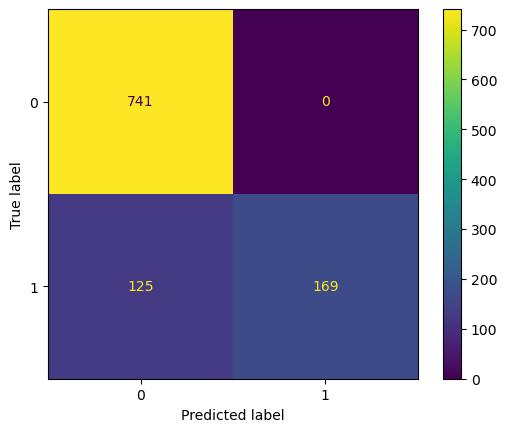

In [40]:
disp=ConfusionMatrixDisplay(cm,display_labels=model_nb.classes_)
disp.plot()